# Notebook 01: Data Loading and Preprocessing

In this notebook, we prepare the MNIST dataset for our Mixture Model experiments. Because we are testing models that assume completely different mathematical properties, we must create two separate versions of our data:

1. **Track A (Continuous & Compressed):** For the Gaussian and Laplacian Mixture Models. We will normalize the pixels and apply Principal Component Analysis (PCA) to reduce dimensionality, making the continuous math stable and fast.


2. **Track B (Discrete/Binary):** For the Bernoulli Mixture Model. We will convert the images into pure black-and-white (1s and 0s) to perfectly match the Bernoulli distribution. No PCA will be applied here, as mixing pixels destroys their binary nature.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
import os

# Create a directory to save our processed data
os.makedirs('data', exist_ok=True)

### 1. Loading MNIST
We will fetch the MNIST dataset using `scikit-learn`. 
* **`X`**: The images, flattened into 1D arrays of 784 pixels.
* **`y`**: The true labels (0-9). We won't use these for training the mixture models, but we need them later to evaluate how well our clusters match the real digits!

In [2]:
print("Fetching MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

X_raw = mnist.data
y_raw = mnist.target.astype(int)

SAMPLE_SIZE = 70000
np.random.seed(42)
indices = np.random.choice(len(X_raw), SAMPLE_SIZE, replace=False)

X = X_raw[indices]
y = y_raw[indices]

print(f"Dataset loaded! Shape of X: {X.shape}")

Fetching MNIST dataset...
Dataset loaded! Shape of X: (70000, 784)


### 2. Track A: Continuous Preprocessing (For Gaussian & Laplacian)


Here we prepare the data for models that assume continuous curves. 
* **Normalization:** We divide by 255.0 to scale pixel values from `[0, 255]` to `[0.0, 1.0]`.
* **PCA (Principal Component Analysis):** A mathematical technique that finds the most important "directions" (components) in the data. By keeping only the top components, we compress the 784 pixels into a smaller set of features while retaining the core visual structure.

**Parameters Definition:**
* `n_components`: The number of features we want to reduce our 784 pixels down to. We will use $50$, which typically retains around 80-85% of the visual variance but makes the Expectation-Maximization math exponentially faster and more stable.

In [3]:
# 1. Normalize
X_continuous = X / 255.0

# 2. Apply PCA
n_components = 50
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_continuous)

variance_retained = np.sum(pca.explained_variance_ratio_)
print(f"Reduced dimensions from 784 to {n_components}.")
print(f"Variance retained: {variance_retained * 100:.2f}%")

Reduced dimensions from 784 to 50.
Variance retained: 82.54%


### 3. Track B: Discrete/Binary Preprocessing (For Bernoulli)


Here we prepare the data for the Bernoulli model, which treats every pixel as a True/False event (Ink vs. No Ink).
* **Binarization (Thresholding):** We set a strict threshold. Any pixel brighter than the threshold becomes a `1`, and anything darker becomes a `0`. 

**Parameters Definition:**
* `threshold`: The pixel intensity value where we draw the line. On our normalized `[0.0, 1.0]` scale, a threshold of $0.5$ works perfectly to isolate the hard pen strokes from the background and anti-aliased gray edges.

In [4]:
threshold = 0.5
# If the normalized pixel is > 0.5, it becomes 1. Else, 0.
X_binary = (X_continuous > threshold).astype(int)

print(f"Binarized data shape: {X_binary.shape}")
print(f"Unique values in binary data: {np.unique(X_binary)}")

Binarized data shape: (70000, 784)
Unique values in binary data: [0 1]


### 4. Visualizing the Transformations
Before saving our data, we will plot a side-by-side comparison of a single digit to ensure our preprocessing didn't destroy the images. We will use `pca.inverse_transform()` to "uncompress" the PCA data back into 28x28 just so we can look at it.

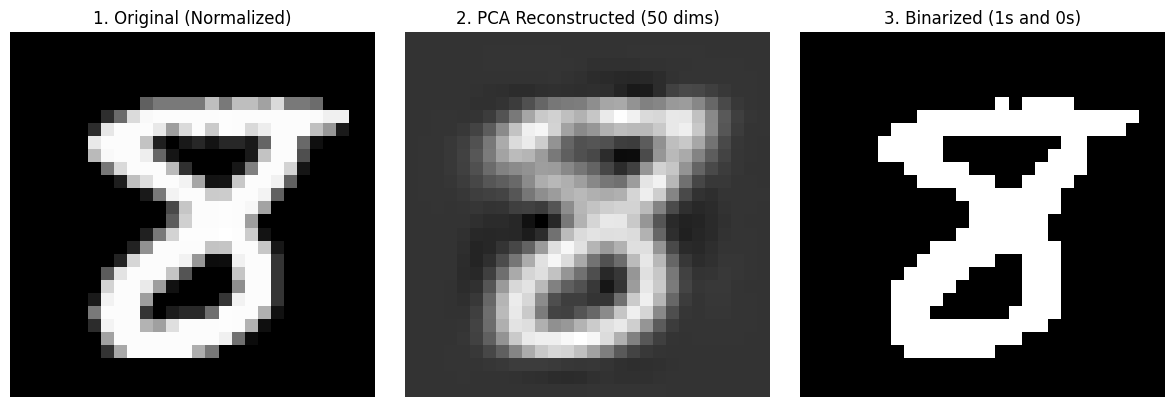

In [7]:
# Pick a random image to visualize
idx = 0 
orig_img = X_continuous[idx].reshape(28, 28)

# Reconstruct the PCA image back to 784 pixels just for visualizing
pca_reconstructed = pca.inverse_transform(X_pca[idx].reshape(1, -1)).reshape(28, 28)

# Reshape the binary image
bin_img = X_binary[idx].reshape(28, 28)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(orig_img, cmap='gray')
axes[0].set_title("1. Original (Normalized)")
axes[0].axis('off')

axes[1].imshow(pca_reconstructed, cmap='gray')
axes[1].set_title(f"2. PCA Reconstructed ({n_components} dims)")
axes[1].axis('off')

axes[2].imshow(bin_img, cmap='gray')
axes[2].set_title("3. Binarized (1s and 0s)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

### 5. Saving the Processed Datasets


In [5]:
import pickle

# Save the arrays
np.save('data/X_pca.npy', X_pca)
np.save('data/X_binary.npy', X_binary)
np.save('data/y_labels.npy', y)

# Save the fitted PCA model using pickle
with open('data/pca_model.pkl', 'wb') as f:
    pickle.dump(pca, f)

print("Preprocessing complete! Data successfully saved to the 'data/' directory.")

Preprocessing complete! Data successfully saved to the 'data/' directory.
